In [155]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches
from pathlib import Path
from aquarel import load_theme

DF_PATH = Path("../data/car_sales_data.csv")
df = pd.read_csv(DF_PATH)

## Cleaning

In [156]:
# look at the datafame
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [157]:
# size of dataframe
df.size

350000

In [158]:
# shape
df.shape

(50000, 7)

In [159]:
# make each column titlecase
df.columns = df.columns.str.title()

In [160]:
# remove duplicates and NaN values
df.drop_duplicates(keep="first", inplace=True)
df.dropna(inplace=True)

In [161]:
# create car age feature
df['Car Age'] = 2025 - df['Year Of Manufacture']

# EXPLORATORY DATA ANALYSIS

### Histogram of prices + Fuel type counts bar plot

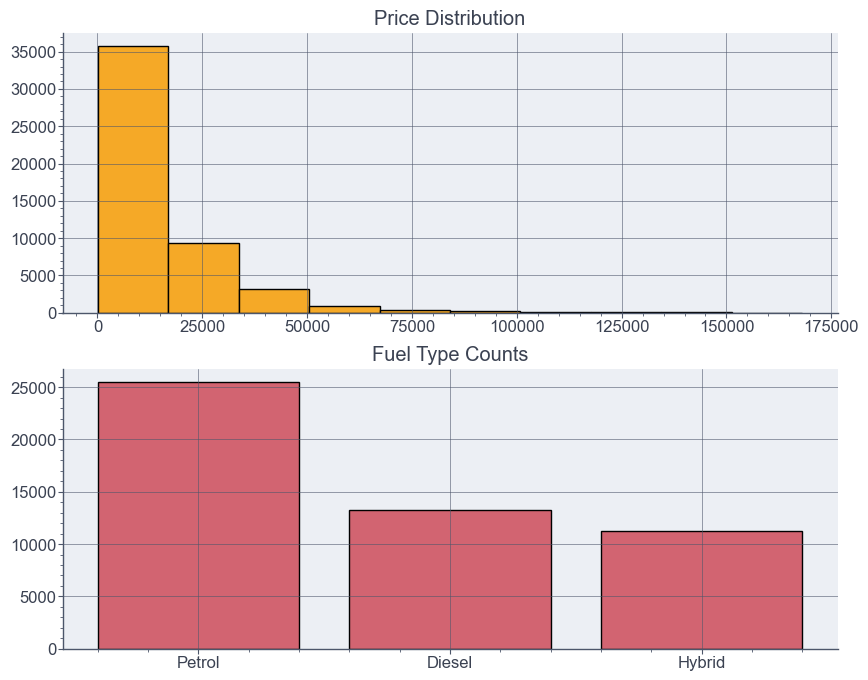

In [ ]:
# setting plot params
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['font.family'] = "monospace"
plt.rcParams['xtick.color'] = "black"
plt.rcParams['ytick.color'] = "black"

# set theme
theme = load_theme("arctic_light")
theme.apply()

fuelTypeCounts = df["Fuel Type"].value_counts()
prices = df["Price"].values

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10,8))

axes[0].hist(prices, bins=10, edgecolor="black", color="#F5A927")
axes[0].set_title("Price Distribution")

axes[1].bar(fuelTypeCounts.index, fuelTypeCounts.values, ec="black",
            color="#d26471")
axes[1].set_title("Fuel Type Counts")
plt.show()

### Price vs Mileage colored by Fuel Type

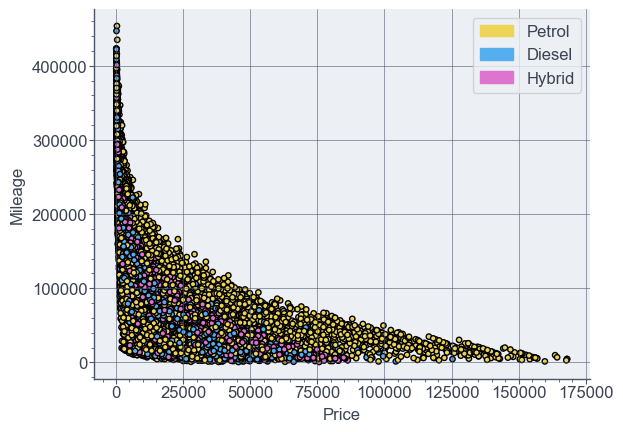

In [163]:
petrol, diesel, hybrid = df['Fuel Type'].unique()
fuelTypes = ["Petrol", "Diesel", "Hybrid"]
colors = {"Petrol": "#EDD455", "Diesel": "#55AEED", "Hybrid": "#DE73D0"}

handles = [mpatches.Patch(color=colors[f], label=f) for f in fuelTypes]

plt.scatter(df['Price'], df['Mileage'], s=15, c=df['Fuel Type'].map(colors),
            edgecolors="black")
plt.xlabel("Price")
plt.ylabel("Mileage")
plt.legend(handles=handles)
plt.show()

### Mean Price By Year

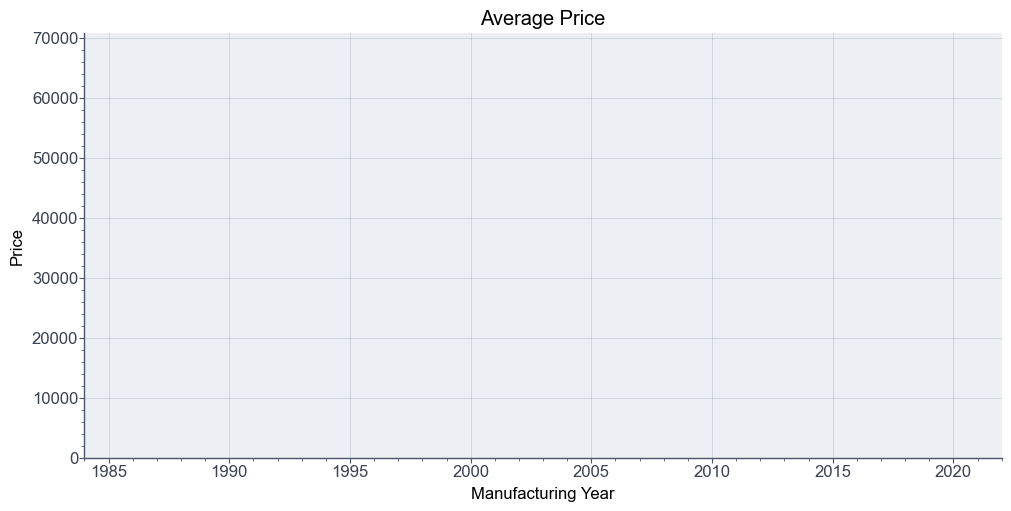

In [164]:
from matplotlib.animation import FuncAnimation
from matplotlib import rc
rc('animation', html='jshtml')

meanPricePerYear = df.groupby("Year Of Manufacture")["Price"].agg("mean").reset_index()
yearOfManufacture = meanPricePerYear['Year Of Manufacture'].values
pricePerYear = meanPricePerYear['Price'].values

fig, axis = plt.subplots(nrows=1, ncols=1, figsize=(10, 5),
                         constrained_layout=True)
# start empty
linePlot, = axis.plot([], [], lw=2, color="#4B92E3")
axis.set_xlim(min(yearOfManufacture), max(yearOfManufacture))
axis.set_ylim(0, max(pricePerYear) * 1.2)
axis.set_xlabel("Manufacturing Year", color="black")
axis.set_ylabel("Price", color="black")
axis.set_title("Average Price", color="black")
axis.grid(alpha=0.3)

def init():
  linePlot.set_data([], [])
  return linePlot,

def update(frames):
  linePlot.set_data(yearOfManufacture[:frames], pricePerYear[:frames])

  return linePlot,

anim = FuncAnimation(
    fig=fig,
    func=update,
    init_func=init,
    frames=len(yearOfManufacture),
    interval=200,
    repeat=True,
    blit=True,
)

anim
plt.show()

### Car longevity
Which fuel type tends to have the highest mileage?



<Figure size 640x480 with 0 Axes>

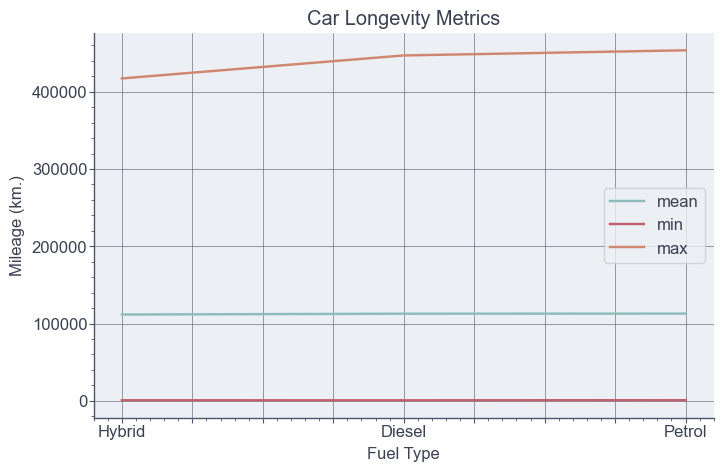

In [ ]:
mileagePerFuelType = df.groupby("Fuel Type")['Mileage'].agg(["mean", "min", "max"])
mileagePerFuelType.sort_values(by="max", ascending=True, inplace=True)
mileagePerFuelType.plot(figsize=(8, 5), ylabel="Mileage (km.)")
plt.title("Car Longevity Metrics")
plt.show()

### How has the average engine size and car price changed with year?

<Figure size 640x480 with 0 Axes>

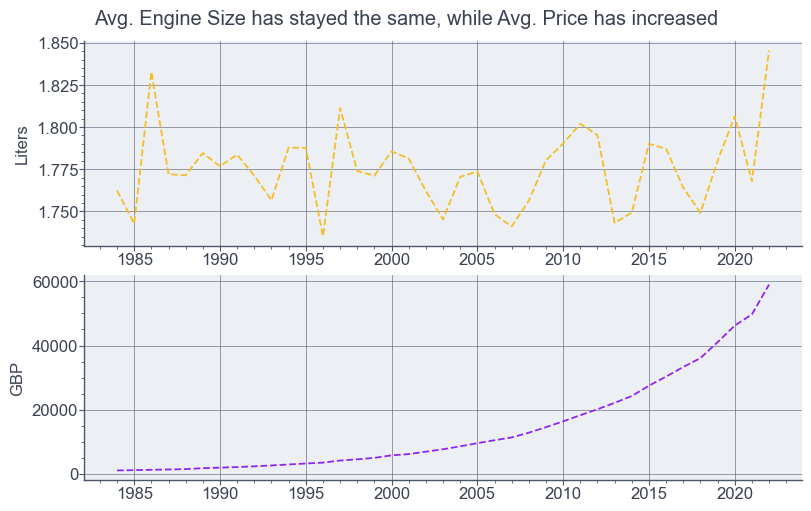

In [ ]:
avgEngineSizeYear = df.groupby("Year Of Manufacture")["Engine Size"].mean()
avgCarPriceYear = df.groupby("Year Of Manufacture")["Price"].mean()

avgDfYear = pd.concat([avgEngineSizeYear, avgCarPriceYear], axis=1)

fig, axes = plt.subplots(nrows=2, ncols=1, constrained_layout=True, figsize=(8, 5))

axes[0].plot(avgDfYear.index, avgDfYear["Engine Size"].values,
             linestyle="--", linewidth=1.3, color="#F5BE27")
axes[0].set_ylabel("Liters")
axes[1].plot(avgDfYear.index, avgDfYear["Price"].values,
             linestyle="--", linewidth=1.3, color="#8E27F5")
axes[1].set_ylabel("GBP")
plt.suptitle("Avg. Engine Size has stayed the same, while Avg. Price has increased")
plt.show()

### Car Age Histogram

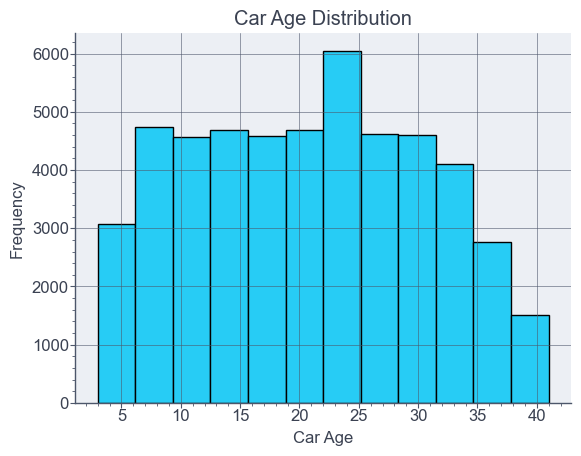

In [167]:
numBins = 12
df['Car Age'].plot(kind="hist", bins=numBins, edgecolor="black",
                   color="#27CCF5", xlabel="Car Age")
plt.title("Car Age Distribution")
plt.show()

### Year of Manufacture vs. Average Price


<Figure size 640x480 with 0 Axes>

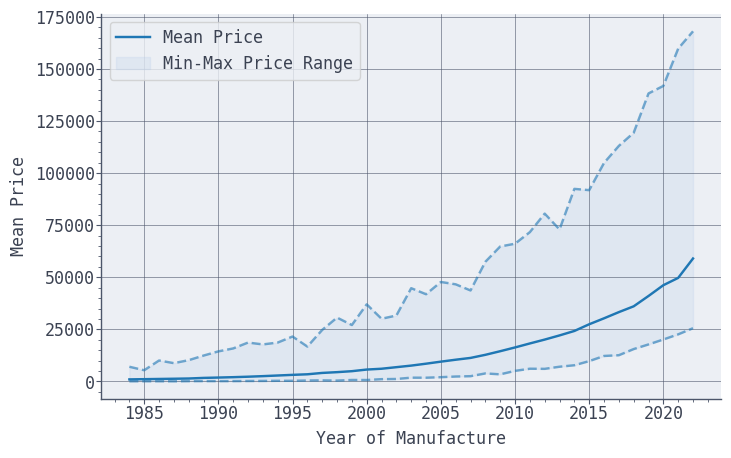

In [ ]:
# Aggregate by year and plot the average price trend
# Then use fill_between to shade the min-max price range or interquartile range for each year

metricsPricePerYear = df.groupby("Year Of Manufacture")["Price"].agg(["min", "max", "mean", "quantile"])
metricsPricePerYear.columns = ["Min", "Max", "Mean", "Quantile"]
metricsPricePerYear = metricsPricePerYear.round(2)

plt.rcParams['font.family'] = "monospace"
plt.figure(figsize=(8, 5))
plt.plot(metricsPricePerYear.index, metricsPricePerYear["Mean"],
         label="Mean Price", color="#1f77b4")
plt.plot(metricsPricePerYear.index, metricsPricePerYear["Min"], alpha=0.6,
         color="#1f77b4", ls="--")
plt.plot(metricsPricePerYear.index, metricsPricePerYear["Max"], alpha=0.6,
         color="#1f77b4", ls="--")
plt.fill_between(metricsPricePerYear.index, metricsPricePerYear["Min"],
                 metricsPricePerYear["Max"], alpha=0.2, color="#aec7e8",
                 label="Min-Max Price Range")
plt.legend(loc="best")
plt.xlabel("Year of Manufacture")
plt.ylabel("Mean Price")
plt.show()

## MACHINE LEARNING

## Predicting car prices using year of manufacture (regression)

In [169]:
df.corr(method="pearson", numeric_only=True) # year of manufacture is the most correlated with price

,Engine Size,Year Of Manufacture,Mileage,Price,Car Age
Engine Size,1.000000,-0.000670,0.004365,0.398391,0.000670
Year Of Manufacture,-0.000670,1.000000,-0.807643,0.714195,-1.000000
Mileage,0.004365,-0.807643,1.000000,-0.632817,0.807643
Price,0.398391,0.714195,-0.632817,1.000000,-0.714195
Car Age,0.000670,-1.000000,0.807643,-0.714195,1.000000


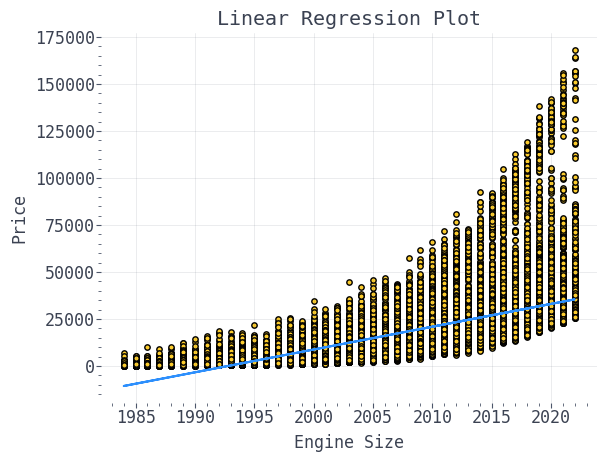

MSE: 132339867.96620281
R2: 0.5084783432292737
MAE: 7079.476794180811
MAPE: 1.4988928991904884


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# scaling the data
scX = StandardScaler()
scY = StandardScaler()
X = scX.fit_transform(df[["Year Of Manufacture"]])
y = scY.fit_transform(df[["Price"]])

xTrain, xTest, yTrain, yTest = train_test_split(X, y, test_size=0.2,
                                                random_state=42)
regr = LinearRegression()
regr.fit(xTrain, yTrain)

yPredTrain = regr.predict(xTrain)
yPredTest = regr.predict(xTest)

# scaling back data
xTrainInv = scX.inverse_transform(xTrain)
yTrainInv = scY.inverse_transform(yTrain)
yPredTrainInv = scY.inverse_transform(yPredTrain)

# visualizing training set
plt.scatter(xTrainInv, yTrainInv, ec="black", color="#FCCC2D", s=15)
plt.plot(xTrainInv, yPredTrainInv,
         color="#2D8FFC", lw=1.5)
plt.xlabel("Engine Size")
plt.box(on=False)
plt.ylabel("Price")
plt.grid(alpha=0.2)
plt.title("Linear Regression Plot")
plt.show()

# metrics
meanSqrError = mean_squared_error(yTrainInv, yPredTrainInv)
r2 = r2_score(yTrainInv, yPredTrainInv)
mae = mean_absolute_error(yTrainInv, yPredTrainInv)
mape = mean_absolute_percentage_error(yTrainInv, yPredTrainInv)

print(f"MSE: {meanSqrError}")
print(f"R2: {r2}")
print(f"MAE: {mae}")
print(f"MAPE: {mape}")

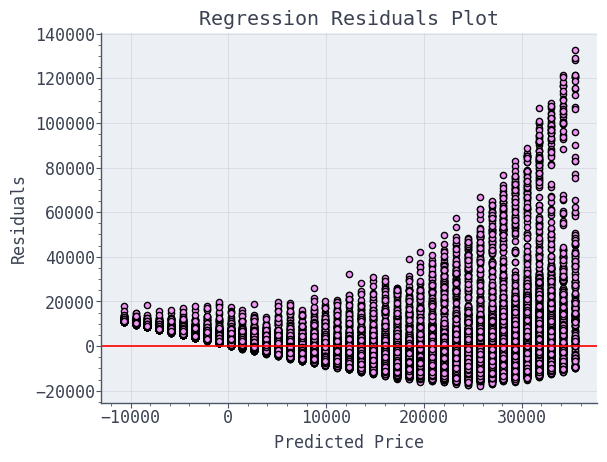

In [ ]:
# residuals
residuals = yTrainInv - yPredTrainInv
plt.scatter(yPredTrainInv, residuals, ec="black", color="#F192F6", s=20)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.grid(alpha=0.2)
plt.axhline(y=0, color="red", lw=1.2)
plt.title("Regression Residuals Plot")
plt.show()

### Random Forest Classification

In [172]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV

# creating categorical variable from Price
bins = [0, 10000, 30000, 100000]
labels = ["Low", "Medium", "High"]
df["Price Categorical"] = pd.cut(df["Price"], bins=bins, labels=labels)

# dummies
dfCleaned = df.dropna(axis=0, subset=["Price Categorical"])
xForestClass = dfCleaned[["Mileage", "Engine Size", "Year Of Manufacture"]]
xForestClass = pd.get_dummies(xForestClass, drop_first=True)
yForestClass = dfCleaned["Price Categorical"]

xTrainFor, xTestFor, yTrainFor, yTestFor = train_test_split(xForestClass, yForestClass,
                                                test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42, bootstrap=True)
rf.fit(xTrainFor, yTrainFor)
rfYPred = rf.predict(xTestFor)

# metrics
cm = confusion_matrix(yTestFor, rfYPred)
rep = classification_report(yTestFor, rfYPred)
print(f"Confusion Matrix: {cm}")
print(f"Report: {rep}")

Confusion Matrix: [[ 930    0  234]
 [   0 5396  283]
 [ 227  250 2629]]
Report:               precision    recall  f1-score   support

        High       0.80      0.80      0.80      1164
         Low       0.96      0.95      0.95      5679
      Medium       0.84      0.85      0.84      3106

    accuracy                           0.90      9949
   macro avg       0.87      0.87      0.87      9949
weighted avg       0.90      0.90      0.90      9949



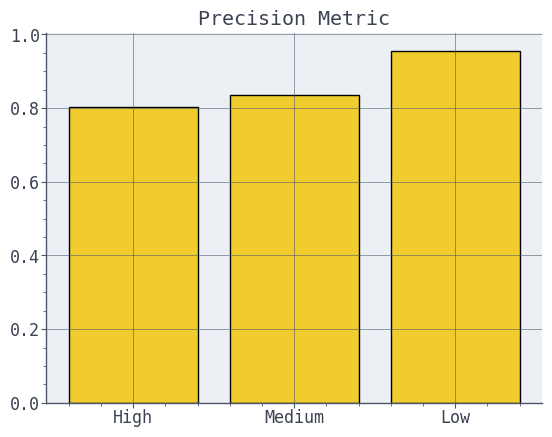

In [173]:
repDict = classification_report(yTestFor, rfYPred, output_dict=True)

# high, medium, low precision
precisions = [repDict["High"]["precision"], repDict["Medium"]["precision"],
              repDict["Low"]["precision"]]
labels = ["High", "Medium", "Low"]

# bar plot
plt.bar(labels, precisions, ec="black", color="#F0CC2E")
plt.title("Precision Metric")
plt.show()

In [174]:
# choosing the best model
paramGrid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

grSCV = GridSearchCV(estimator=rf, param_grid=paramGrid, cv=5, n_jobs=-1, verbose=2)
grSCV.fit(xTrainFor, yTrainFor)

# best model metrics
print(f"Best Score: {grSCV.best_score_}")
print(f"Best Params: {grSCV.best_params_}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Score: 0.9176278426938058
Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


## Key Findings

### Exploratory Data Analysis (EDA)

1.	Price isn’t normally distributed, as shown by the right-skewed histogram. Most of the cars cost less than £50k, with a minority being more than £100k. 
2.	Fuel types are petrol, diesel and hybrid, with petrol representing a large part of the data. 
3.	For all types of fuels, as price increases mileage decreases, according to the car data. The scatter plot suggests an inverse relationship between mileage and price. Cars with higher mileage generally tend to have lower prices, which is expected because vehicles depreciate as they accumulate wear and usage over time.
4.	Each fuel type (hybrid, petrol and diesel) doesn’t show higher/lower mean mileage. According to the dataset, the average is almost the same.
5.	To note, the average engine size has stayed relatively the same in the last few decades while the average car price has increased by many factors. It’s also important to keep in mind that prices have a wide range, thereby offering people a choice based on their needs.

### Machine Learning

#### Linear Regression

-	The linear regression model used to predict car price using year of manufacture demonstrates a high enough correlation between the two features (0.71 Pearson Coeff.). The linear regression model achieves an R² score of approximately 0.51, meaning that around 51% of the variance in car prices can be explained by the year of manufacture alone. This indicates a moderate relationship between the variables, although a substantial amount of variability remains unexplained.
-	Furthermore, the mean absolute error of 7079 demonstrates that the model isn’t perfect but neither bad. On average, it gets price predictions wrong by £7079.
-	The Mean Squared Error is relatively large because squared errors heavily penalize large prediction mistakes. This suggests that the model occasionally makes substantial errors when predicting car prices, particularly for extreme values or outliers.

#### Random Forest Classifier

-	Using random forest classifier to predict price category produces great results in terms of metrics.
-	The model achieves an accuracy score of 90%, which is high but needs to be further confirmed by other metrics because it can be distorted in imbalanced datasets.
-	The model is pretty good at detecting expensive cars. When it makes mistakes, it usually downgrades them to Medium instead of Low. It performs well on cheap cars and almost never confuses them with High-priced ones. Medium-priced cars are the hardest to classify.
-	Regarding precision, the model is correct 96% of the time when predicting Low category. Precision for Medium category also remains high at 0.84, meaning that the model doesn’t show struggles when predicting a class.
-	One other note is that the model finds 80% of all actual High-priced cars, which is the lowest score among the categories. It almost gets all Low-priced cars correctly, showed by the 0.95 recall score.

One limitation of this analysis is that the dataset appears to be synthetic or artificially generated. Certain unrealistic combinations of features are present, such as hybrid vehicles manufactured before hybrid technology became commercially common. Therefore, while the dataset is useful for practicing data analysis and machine learning techniques, the conclusions may not fully reflect real-world automotive market behavior.